      DATA AUTOMATION AND REPORTING SYSTEM

Creating Sample Dataset...

Original Dataset
   Employee_ID   Name Department   Salary  Experience
0          101  Rahul         IT  50000.0         2.0
1          102  Priya         HR  45000.0         3.0
2          103   Amit        it       NaN         1.0
3          104  Sneha    Finance  55000.0         5.0
4          105   None         HR  48000.0         2.0
5          106  Karan         IT  60000.0         4.0
6          106  Karan         IT  60000.0         4.0
7          107   Riya   finance   52000.0         NaN

DATA QUALITY REPORT

Missing Values
Employee_ID    0
Name           1
Department     0
Salary         1
Experience     1
dtype: int64

Duplicate Records : 1

Cleaning Data...
Duplicates Removed : 1

Cleaned Dataset
   Employee_ID     Name Department        Salary  Experience
0          101    Rahul         IT  50000.000000    2.000000
1          102    Priya         HR  45000.000000    3.000000
2          103     Amit   

C:\Users\nayak\AppData\Local\Temp\ipykernel_11208\1570719633.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Name"] = df["Name"].fillna("Unknown")
C:\Users\nayak\AppData\Local\Temp\ipykernel_11208\1570719633.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Department"] = (
C:\Users\nayak\AppData\Local\Temp\ipykernel_11208\1570719633.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

Highest Salary : 60000.0
Lowest Salary : 45000.0
Average Experience : 2.83 Years

Employees by Department
Department
IT         3
HR         2
FINANCE    2
Name: count, dtype: int64

Salary by Department
Department
FINANCE    53500.000000
HR         46500.000000
IT         53888.888889
Name: Salary, dtype: float64

Statistical Summary
       Employee_ID        Salary  Experience
count     7.000000      7.000000    7.000000
mean    104.000000  51666.666667    2.833333
std       2.160247   4853.406593    1.343710
min     101.000000  45000.000000    1.000000
25%     102.500000  49000.000000    2.000000
50%     104.000000  51666.666667    2.833333
75%     105.500000  53500.000000    3.500000
max     107.000000  60000.000000    5.000000

Excel Reports Saved Successfully


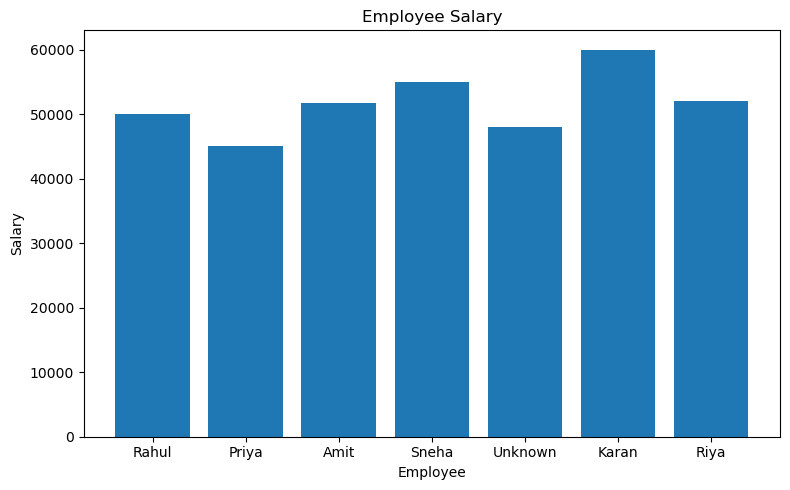

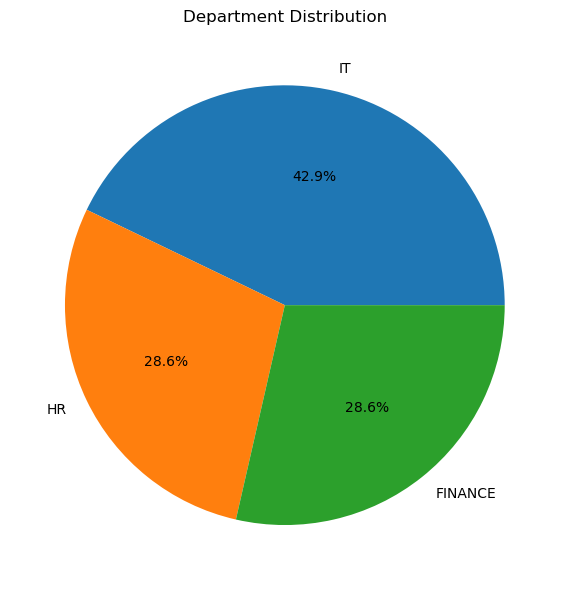

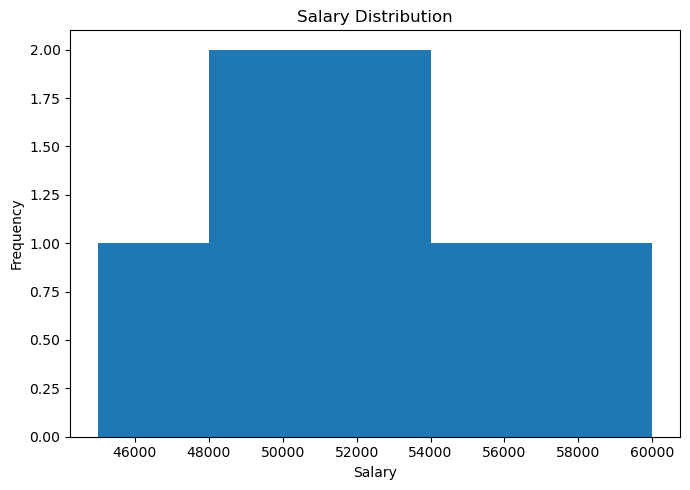


PROJECT COMPLETED SUCCESSFULLY
Generated Files:
1. Cleaned_Report.xlsx
2. Summary_Report.xlsx
3. Salary_BarChart.png
4. Department_PieChart.png
5. Salary_Histogram.png


In [2]:
# ============================================================
#          DATA AUTOMATION AND REPORTING PROJECT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1 : CREATE SAMPLE DATA
# ============================================================

def create_data():
    data = {
        "Employee_ID": [101,102,103,104,105,106,106,107],
        "Name": ["Rahul","Priya","Amit","Sneha",None,"Karan","Karan","Riya"],
        "Department": ["IT","HR"," it ","Finance","HR","IT","IT"," finance "],
        "Salary": [50000,45000,None,55000,48000,60000,60000,52000],
        "Experience": [2,3,1,5,2,4,4,None]
    }

    return pd.DataFrame(data)

# ============================================================
# STEP 2 : DATA QUALITY CHECK
# ============================================================

def data_quality(df):

    print("\n==============================")
    print("DATA QUALITY REPORT")
    print("==============================")

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Records :", df.duplicated().sum())

# ============================================================
# STEP 3 : DATA CLEANING
# ============================================================

def clean_data(df):

    print("\nCleaning Data...")

    # Remove duplicate rows
    duplicate_before = df.duplicated().sum()
    df = df.drop_duplicates()

    # Fill missing text values
    df["Name"] = df["Name"].fillna("Unknown")

    # Clean Department names
    df["Department"] = (
        df["Department"]
        .str.strip()
        .str.upper()
    )

    # Fill missing Salary with average
    df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

    # Fill missing Experience with average
    df["Experience"] = df["Experience"].fillna(df["Experience"].mean())

    print("Duplicates Removed :", duplicate_before)

    return df

# ============================================================
# STEP 4 : SUMMARY REPORT
# ============================================================

def summary_report(df):

    print("\n==============================")
    print("SUMMARY REPORT")
    print("==============================")

    print("Total Employees :", len(df))
    print("Average Salary :", round(df["Salary"].mean(),2))
    print("Highest Salary :", df["Salary"].max())
    print("Lowest Salary :", df["Salary"].min())
    print("Average Experience :", round(df["Experience"].mean(),2),"Years")

    print("\nEmployees by Department")
    print(df["Department"].value_counts())

    print("\nSalary by Department")
    print(df.groupby("Department")["Salary"].mean())

    print("\nStatistical Summary")
    print(df.describe())

# ============================================================
# STEP 5 : SAVE REPORTS
# ============================================================

def save_reports(df):

    df.to_excel("Cleaned_Report.xlsx", index=False)

    summary = df.describe(include="all")
    summary.to_excel("Summary_Report.xlsx")

    print("\nExcel Reports Saved Successfully")

# ============================================================
# STEP 6 : VISUALIZATION
# ============================================================

def create_charts(df):

    # Salary Bar Chart
    plt.figure(figsize=(8,5))
    plt.bar(df["Name"], df["Salary"])
    plt.title("Employee Salary")
    plt.xlabel("Employee")
    plt.ylabel("Salary")
    plt.tight_layout()
    plt.savefig("Salary_BarChart.png")
    plt.show()

    # Department Pie Chart
    plt.figure(figsize=(6,6))
    df["Department"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%"
    )
    plt.title("Department Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("Department_PieChart.png")
    plt.show()

    # Salary Histogram
    plt.figure(figsize=(7,5))
    plt.hist(df["Salary"], bins=5)
    plt.title("Salary Distribution")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("Salary_Histogram.png")
    plt.show()

# ============================================================
# STEP 7 : MAIN PROGRAM
# ============================================================

print("="*55)
print("      DATA AUTOMATION AND REPORTING SYSTEM")
print("="*55)

print("\nCreating Sample Dataset...")

df = create_data()

print("\nOriginal Dataset")
print(df)

# Check Data Quality
data_quality(df)

# Clean Data
df = clean_data(df)

print("\nCleaned Dataset")
print(df)

# Generate Report
summary_report(df)

# Save Reports
save_reports(df)

# Create Charts
create_charts(df)

print("\n==============================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("==============================================")
print("Generated Files:")
print("1. Cleaned_Report.xlsx")
print("2. Summary_Report.xlsx")
print("3. Salary_BarChart.png")
print("4. Department_PieChart.png")
print("5. Salary_Histogram.png")
print("==============================================")